In [2]:
import pandas as pd

df = pd.read_csv("ACSST1Y2024.S1901-Data.csv", skiprows=1)

df.head()

,Geography,Geographic Area Name,Estimate!!Households!!Total,Margin of Error!!Households!!Total,"Estimate!!Households!!Total!!Less than $10,000","Margin of Error!!Households!!Total!!Less than $10,000","Estimate!!Households!!Total!!$10,000 to $14,999","Margin of Error!!Households!!Total!!$10,000 to $14,999","Estimate!!Households!!Total!!$15,000 to $24,999","Margin of Error!!Households!!Total!!$15,000 to $24,999",...,Margin of Error!!Nonfamily households!!Median income (dollars),Estimate!!Nonfamily households!!Mean income (dollars),Margin of Error!!Nonfamily households!!Mean income (dollars),Estimate!!Nonfamily households!!PERCENT ALLOCATED!!Household income in the past 12 months,Margin of Error!!Nonfamily households!!PERCENT ALLOCATED!!Household income in the past 12 months,Estimate!!Nonfamily households!!PERCENT ALLOCATED!!Family income in the past 12 months,Margin of Error!!Nonfamily households!!PERCENT ALLOCATED!!Family income in the past 12 months,Estimate!!Nonfamily households!!PERCENT ALLOCATED!!Nonfamily income in the past 12 months,Margin of Error!!Nonfamily households!!PERCENT ALLOCATED!!Nonfamily income in the past 12 months,Unnamed: 130
0,0500000US24031,"Montgomery County, Maryland",389161,3250,3.7,0.7,1.7,0.4,3.1,0.5,...,4929,99066,4419,(X),(X),(X),(X),28.8,(X),NaN
1,0500000US24033,"Prince George's County, Maryland",353909,2507,5.3,0.9,2.2,0.6,3.6,0.8,...,4333,81543,6181,(X),(X),(X),(X),35.6,(X),NaN


In [3]:
import pandas as pd

df = pd.read_csv("ACSST1Y2024.S1901-Data.csv", skiprows=1)

df.head()

,Geography,Geographic Area Name,Estimate!!Households!!Total,Margin of Error!!Households!!Total,"Estimate!!Households!!Total!!Less than $10,000","Margin of Error!!Households!!Total!!Less than $10,000","Estimate!!Households!!Total!!$10,000 to $14,999","Margin of Error!!Households!!Total!!$10,000 to $14,999","Estimate!!Households!!Total!!$15,000 to $24,999","Margin of Error!!Households!!Total!!$15,000 to $24,999",...,Margin of Error!!Nonfamily households!!Median income (dollars),Estimate!!Nonfamily households!!Mean income (dollars),Margin of Error!!Nonfamily households!!Mean income (dollars),Estimate!!Nonfamily households!!PERCENT ALLOCATED!!Household income in the past 12 months,Margin of Error!!Nonfamily households!!PERCENT ALLOCATED!!Household income in the past 12 months,Estimate!!Nonfamily households!!PERCENT ALLOCATED!!Family income in the past 12 months,Margin of Error!!Nonfamily households!!PERCENT ALLOCATED!!Family income in the past 12 months,Estimate!!Nonfamily households!!PERCENT ALLOCATED!!Nonfamily income in the past 12 months,Margin of Error!!Nonfamily households!!PERCENT ALLOCATED!!Nonfamily income in the past 12 months,Unnamed: 130
0,0500000US24031,"Montgomery County, Maryland",389161,3250,3.7,0.7,1.7,0.4,3.1,0.5,...,4929,99066,4419,(X),(X),(X),(X),28.8,(X),NaN
1,0500000US24033,"Prince George's County, Maryland",353909,2507,5.3,0.9,2.2,0.6,3.6,0.8,...,4333,81543,6181,(X),(X),(X),(X),35.6,(X),NaN


In [4]:
[c for c in df.columns if "Median income" in c]

['Estimate!!Households!!Median income (dollars)',
 'Margin of Error!!Households!!Median income (dollars)',
 'Estimate!!Families!!Median income (dollars)',
 'Margin of Error!!Families!!Median income (dollars)',
 'Estimate!!Married-couple families!!Median income (dollars)',
 'Margin of Error!!Married-couple families!!Median income (dollars)',
 'Estimate!!Nonfamily households!!Median income (dollars)',
 'Margin of Error!!Nonfamily households!!Median income (dollars)']

In [5]:
median_col = 'Estimate!!Households!!Median income (dollars)'

clean_df = df[['Geographic Area Name', median_col]].copy()

clean_df.rename(columns={
    'Geographic Area Name': 'County',
    median_col: 'MedianIncome'
}, inplace=True)

clean_df

,County,MedianIncome
0,"Montgomery County, Maryland",140837
1,"Prince George's County, Maryland",99180


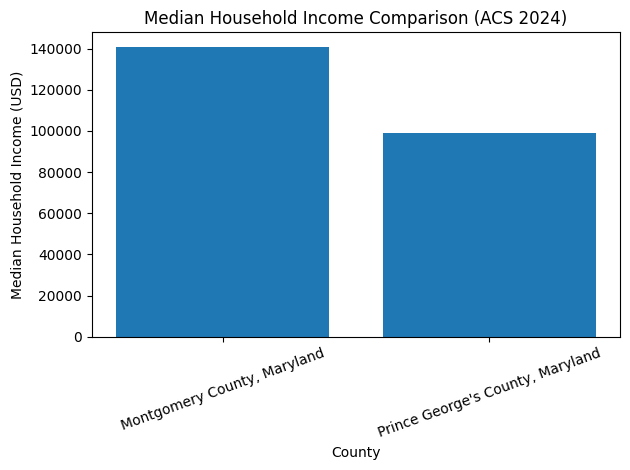

In [6]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(clean_df["County"], clean_df["MedianIncome"])

plt.xlabel("County")
plt.ylabel("Median Household Income (USD)")
plt.title("Median Household Income Comparison (ACS 2024)")

plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

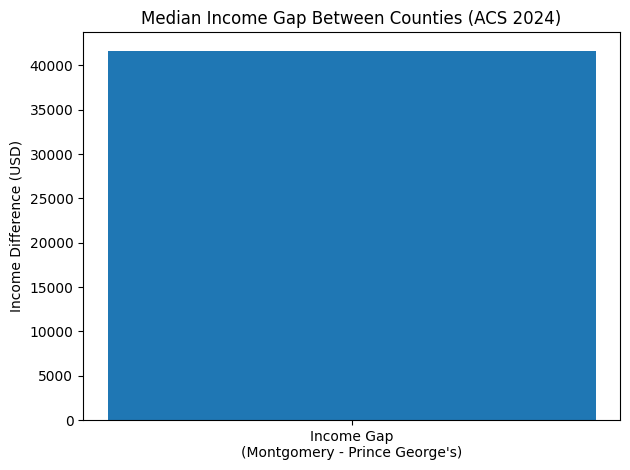

np.int64(41657)

In [7]:
gap = clean_df["MedianIncome"].iloc[0] - clean_df["MedianIncome"].iloc[1]

plt.figure()

plt.bar(["Income Gap\n(Montgomery - Prince George's)"], [gap])

plt.ylabel("Income Difference (USD)")
plt.title("Median Income Gap Between Counties (ACS 2024)")

plt.tight_layout()
plt.show()

gap

In [8]:
# Save Visualization 1
plt.figure()
plt.bar(clean_df["County"], clean_df["MedianIncome"])
plt.xlabel("County")
plt.ylabel("Median Household Income (USD)")
plt.title("Median Household Income Comparison (ACS 2024)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("Visualization1_IncomeComparison.png", dpi=300)
plt.close()

# Save Visualization 2
gap = clean_df["MedianIncome"].iloc[0] - clean_df["MedianIncome"].iloc[1]

plt.figure()
plt.bar(["Income Gap\n(Montgomery - Prince George's)"], [gap])
plt.ylabel("Income Difference (USD)")
plt.title("Median Income Gap Between Counties (ACS 2024)")
plt.tight_layout()
plt.savefig("Visualization2_IncomeGap.png", dpi=300)
plt.close()

In [9]:
!pip install python-pptx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 11.6 MB/s eta 0:00:00


In [11]:
from pptx import Presentation
from pptx.util import Inches

prs = Presentation()
layout = prs.slide_layouts[5]

# Slide 1
slide1 = prs.slides.add_slide(layout)
slide1.shapes.title.text = "Visualization 1: Median Household Income (ACS 2024)"
slide1.shapes.add_picture("Visualization1_IncomeComparison.png", Inches(1), Inches(1.5), width=Inches(8))

# Slide 2
slide2 = prs.slides.add_slide(layout)
slide2.shapes.title.text = "Visualization 2: Median Income Gap (ACS 2024)"
slide2.shapes.add_picture("Visualization2_IncomeGap.png", Inches(1), Inches(1.5), width=Inches(8))

file_name = "DATA205_32096_Homework5B_FarahMakkawi.pptx"
prs.save(file_name)

file_name

'DATA205_32096_Homework5B_FarahMakkawi.pptx'